# Gradient testing

We use:

$$\psi_\alpha(x) = \frac{1}{x^2+\alpha^2}$$

to compute the energy of a harmonic oscillator:

$$H = -\frac{1}{2}\partial^2_x + \frac12 x^2 .$$

We define the local energy

$$E_L(x) = \frac{H\psi}{\psi} = -\frac{1}{2\psi}\partial^2_x\psi + \frac12 x^2 .$$

And we can compute the expectation value of the Hamiltonian (energy) with Monte Carlo integration:

$$\mathbf E = \mathbb E_{x_i\sim \psi^2}[E_L(x_i)]$$

Where $\mathbb E_{x_i\sim \psi^2}[]$ indicates the mean value with $x_i$ distributed with the pdf $\psi^2$.

### VMC gradient formula

From the paper [Accurate Computation of Quantum Excited States with Neural Networks](https://arxiv.org/pdf/2308.16848) we have:

$$\nabla_\theta\frac{\langle\psi | H | \psi\rangle}{\langle \psi |\psi \rangle} = 2\mathbb{E}_{x_i\sim \psi^2}[(E_L(x_i)-\mathbf E)\nabla_\theta \ln|\psi_\alpha(x_i)|] = 2\mathbb E_{x_i\sim \psi^2}[E_L(x_i)\nabla_\theta \ln|\psi_\alpha(x_i)|]-2\mathbf E \mathbb E_{x_i\sim \psi^2}[\nabla_\theta \ln|\psi_\alpha(x_i)|]$$

In our case, $\theta = \{\alpha\}$ and we can compute $\nabla_\theta \ln|\psi_\alpha(x)|$:

$$\nabla_\theta \ln|\psi_\alpha(x)| = \frac{\nabla_\alpha \ln\psi_\alpha(x)}{\psi_\alpha(x)} = (\alpha^2+x^2)\cdot\bigg(-\frac{1}{(\alpha^2+x^2)^2}\bigg)2\alpha = -\frac{2\alpha}{\alpha^2+x^2}$$

In [4]:
import jax
import jax.numpy as jnp
from jax import random
import flax.linen as nn

from jax.scipy.integrate import trapezoid

In [ ]:
# compute kinetic term with AD (correct)
def local_energy_batch(params, xs, model_apply):
    # xs: (batch, 1) or (batch,)
    xs_flat = xs.squeeze()  # shape (batch,)

    # psi(x) -> scalar
    def psi_fn(x):
        # ensure input has shape (1,) as model expects last-dim features
        return model_apply(params, x.reshape(1, 1)).squeeze()

    # second derivative per sample via AD
    d2psi_fn = jax.vmap(jax.jacfwd(jax.grad(psi_fn)))
    d2psi = d2psi_fn(xs_flat)  # shape (batch,)
    psi_vals = jax.vmap(lambda x: psi_fn(x))(xs_flat)  # shape (batch,)

    # avoid division by zero / small psi
    psi_safe = psi_vals + 1e-12

    kinetic = -0.5 * (d2psi / psi_safe)  # shape (batch,)
    potential = 0.5 * (xs_flat**2)  # shape (batch,)
    return (kinetic + potential).reshape(-1, 1)  # keep your (batch,1) convention


def log_psi(x, params, model_apply):
    psi = model_apply(params, x)
    return jnp.log(jnp.abs(psi) + 1e-8).squeeze()  # Add small constant to avoid log(0)


grad_log_psi = jax.grad(
    lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0
)  # CAREFUL WITH THE DERIVATIVES: WE WANT THE GRADIENT WRT THE PARAMETERS, so we turn the order of the p and x

# now grad_log_psi is a function that takes (params, x, model_apply) and returns the gradient of log_psi wrt params


def energy_fn(params, batch, model_apply):
    local_energy_per_point = local_energy_batch(params, batch, model_apply)
    E = jnp.mean(local_energy_per_point)
    return E


def energy_fn_trapezoidal(params, batch, model_apply):
    psi = jax.vmap(lambda x: model_apply(params, x))(batch)
    psi_squared = jnp.abs(psi) ** 2
    local_energy_per_point = local_energy_batch(params, batch, model_apply)

    energy_integrand = psi_squared * local_energy_per_point
    norm = trapezoid(psi_squared.squeeze(), batch.squeeze())
    integral = trapezoid(energy_integrand.squeeze(), batch.squeeze())
    return integral / norm


def compute_energy_with_traps_and_MC(params, batch, model_apply):
    E = energy_fn(params, batch, model_apply)
    E_trap = energy_fn_trapezoidal(
        params, jnp.linspace(-5, 5, 1000).reshape(-1, 1), model_apply
    )
    grad_E_trapezoidal = jax.grad(energy_fn_trapezoidal, argnums=0)(
        params, jnp.linspace(-5, 5, 1000).reshape(-1, 1), model_apply
    )
    jax.debug.print("---- Monte Carlo integral ----")
    jax.debug.print("E: {}", E)
    jax.debug.print("---- Trapezoidal Rule ----")
    jax.debug.print("E_trap: {}", E_trap)
    jax.debug.print("-----------------------------")
    return E_trap, grad_E_trapezoidal

In [28]:
from functools import partial
import jax
from jax import random
from jax import numpy as jnp


@partial(jax.jit, static_argnums=(1,))
def mh_kernel(rng_key, prob_fn, prob_params, position, prob, PBC=None):
    key1, key2 = random.split(rng_key)
    # proposal = position + random.normal(key1, shape=position.shape) * 0.5
    proposal = position + random.uniform(
        key1, shape=position.shape, minval=-1, maxval=1
    )
    # ensure PBC
    proposal = jax.lax.cond(
        PBC is None,
        lambda p: p,
        lambda p: ((p + 0.5 * PBC) % PBC) - 0.5 * PBC,
        proposal,
    )
    proposal_prob = prob_fn(proposal, prob_params)
    accept_prob = jnp.minimum(1.0, proposal_prob / prob)
    accept = jax.random.uniform(key2) < accept_prob
    # accept = jax.random.uniform(key2) < (proposal_prob / prob)
    new_position = jnp.where(accept, proposal, position)
    new_prob = jnp.where(accept, proposal_prob, prob)
    return new_position, new_prob


@partial(jax.jit, static_argnums=(1, 2, 3))
def mh_chain(rng_key, n_steps, PBC, prob_fn, prob_params, init_position):
    def body_fn(i, val):
        key, position, prob = val
        key, subkey = random.split(key)
        new_position, new_prob = mh_kernel(
            subkey, prob_fn, prob_params, position, prob, PBC=PBC
        )
        return key, new_position, new_prob

    init_prob = prob_fn(init_position, prob_params)
    init_val = (rng_key, init_position, init_prob)
    _, positions, _ = jax.lax.fori_loop(0, n_steps, body_fn, init_val)
    return positions


sampler = jax.vmap(mh_chain, in_axes=(0, None, None, None, None, 0), out_axes=0)

In [29]:
class WavefunctionOneParameter(nn.Module):

    @nn.compact
    def __call__(self, x):
        alpha = self.param("alpha", nn.initializers.constant(0.5), ())
        return 1 / (alpha**2 + x**2)


In [30]:
model_apply = WavefunctionOneParameter().apply
def prob_fn(x, params):
    # Ensure x has a batch dimension, run the MLP, and return non-negative per-input values.
    x = jnp.atleast_1d(x).reshape(-1, 1)  # (batch, 1)
    forward = model_apply(params, x).flatten()  # (batch,)
    out = jnp.square(forward)  # non-negative density probability
    return jnp.squeeze(out)  # scalar for scalar input, (batch,) for batch

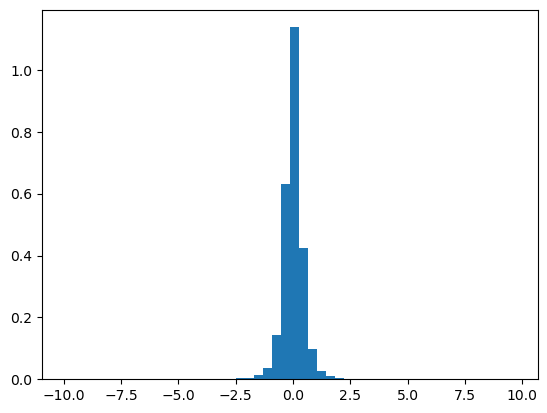

---- Monte Carlo integral ----
E: 1.111829400062561
---- Trapezoidal Rule ----
E_trap: 1.1096845865249634
-----------------------------


In [31]:
equispaced_grid = jnp.linspace(-5, 5, 1000).reshape(-1, 1)
model = WavefunctionOneParameter()
key1 = random.PRNGKey(0)
params = model.init(key1, jnp.array([[0.0]]))  # initialize
num_of_samples = 100000
samples = sampler(
    random.split(random.PRNGKey(1), num=num_of_samples), 1000, 20, prob_fn, params, jnp.zeros((num_of_samples, 1))
)
import matplotlib.pyplot as plt
plt.hist(samples.flatten(), bins=50, density=True)
plt.show()
E, grad_E = compute_energy_with_traps_and_MC(params, samples, model.apply)


In [39]:
def analytic_gradient_log_psi(x, params):
    alpha = params["params"]["alpha"]
    return -(2*alpha)/(alpha**2 + x**2)

def alpha_gradient_VMC(batch, params):
    local_energy_per_point = local_energy_batch(params, batch, model_apply)
    E = energy_fn(params, batch, model_apply)
    E_centered = local_energy_per_point - E
    grad_log_psi_vals = jax.vmap(lambda x: analytic_gradient_log_psi(x, params))(batch)
    grad_E = 2 * jnp.mean(E_centered * grad_log_psi_vals)
    return grad_E

alpha_gradient_VMC(samples, params)
grad_E_trapezoidal = jax.grad(energy_fn_trapezoidal, argnums=0)(
    params, jnp.linspace(-5, 5, 1000).reshape(-1, 1), model_apply
)
jax.debug.print("---- Analytic Gradient log psi ----")
jax.debug.print("grad_E_VMC: {}", alpha_gradient_VMC(samples, params))
jax.debug.print("---- Trapezoidal Rule ----")
jax.debug.print("grad_E_trapezoidal: {}", grad_E_trapezoidal)

def log_psi(x, params, model_apply):
    psi = model_apply(params, x)
    return jnp.log(jnp.abs(psi) + 1e-8).squeeze()  # Add small constant to avoid log(0)

def grad_log_psi(x, params, model_apply):
    return jax.grad(
        lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0
    )(params, x, model_apply)



---- Analytic Gradient log psi ----
grad_E_VMC: -3.5331871509552
---- Trapezoidal Rule ----
grad_E_trapezoidal: {'params': {'alpha': Array(-3.5930066, dtype=float32)}}


In [49]:
# compare analytic with AD
jax.debug.print("---- Comparing Analytic and AD gradients of log psi ----")
x_test = jax.random.uniform(random.PRNGKey(42), shape=(10, 1), minval=-5, maxval=5)
analytic_grads = jax.vmap(lambda x: analytic_gradient_log_psi(x, params))(x_test)

grad_log_psi = jax.grad(
    lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0
)  # CAREFUL WITH THE DERIVATIVES: WE WANT THE GRADIENT WRT THE PARAMETERS, so we turn the order of the p and x
log_psi_grads = jax.vmap(lambda x: grad_log_psi(params, x, model_apply))(x_test)
jax.debug.print("x: {}, analytic_grads: {}, ad_grads: {}", x_test.flatten(), analytic_grads, ad_grads)

---- Comparing Analytic and AD gradients of log psi ----
x: [-0.11290455  1.7979717   1.162715    0.6101608  -0.49355412  0.8586588
 -4.2519054   2.7513337   1.9895926   3.1863365 ], analytic_grads: [[-3.8059363 ]
 [-0.28713337]
 [-0.6242563 ]
 [-1.6069518 ]
 [-2.0259497 ]
 [-1.0128685 ]
 [-0.05455925]
 [-0.1278799 ]
 [-0.23761557]
 [-0.09612852]], ad_grads: {'params': {'alpha': Array([-3.8059363 , -0.28713334, -0.6242564 , -1.6069517 , -2.0259497 ,
       -1.0128686 , -0.05455923, -0.12787989, -0.23761557, -0.09612851],      dtype=float32)}}


In [51]:
def tree_grad_log_psi(x, params, model_apply):
    E = energy_fn(params, x, model_apply)
    local_energy_per_point = local_energy_batch(params, x, model_apply)
    E_centered = local_energy_per_point - E
    # grad_log_psi = jax.grad(
    #     lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0
    # )
    log_psi_grads = jax.vmap(lambda x: grad_log_psi(params, x, model_apply))(x_test)
    grad_E_short = jax.tree_util.tree_map(
        lambda g: 2 * jnp.mean(E_centered[:, None] * g), log_psi_grads
    )
    return grad_E_short


samples = sampler(
    random.split(random.PRNGKey(2), num=num_of_samples), 1000, 20, prob_fn, params, jnp.zeros((num_of_samples, 1))
)   
jax.debug.print("---- Comparing Explicit and AD gradients of the energy ----")
grad_E_short = tree_grad_log_psi(samples, params, model_apply)
E, grad_E_trapzs = compute_energy_with_traps_and_MC(params, samples, model_apply)

jax.debug.print("E: {}, grad_E_explicit: {}, grad_E_trapezoidal: {}", E, grad_E_short, grad_E_trapzs)

---- Comparing Explicit and AD gradients of the energy ----
---- Monte Carlo integral ----
E: 1.1161878108978271
---- Trapezoidal Rule ----
E_trap: 1.1096845865249634
-----------------------------
E: 1.1096845865249634, grad_E_explicit: {'params': {'alpha': Array(-1.5039062e-07, dtype=float32)}}, grad_E_trapezoidal: {'params': {'alpha': Array(-3.5930066, dtype=float32)}}
